In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(3,3,0), "XN", "control-int"),
    (Position3DHex(3,3,1), "NN", ""),
    (Position3DHex(3,3,2), "NN", ""),
    (Position3DHex(3,3,3), "NX", "control-out"),

    (Position3DHex(2,2,1), "XN", ""),
    (Position3DHex(2,2,2), "NZ", ""),

    (Position3DHex(1,3,0), "XN", "target-in"),
    (Position3DHex(1,3,1), "NN", ""),
    (Position3DHex(1,3,2), "NN", ""),
    (Position3DHex(1,3,3), "NX", "target-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#c temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

g.view_as_html()

In [3]:
"""
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(3,3,0), "XN", "control-int"),
    (Position3DHex(3,3,1), "NN", ""),
    (Position3DHex(3,3,2), "NN", ""),
    (Position3DHex(3,3,3), "NX", "control-out"),

    (Position3DHex(2,2,1), "ZN", ""),
    (Position3DHex(2,2,2), "NX", ""),

    (Position3DHex(1,3,0), "XN", "target-in"),
    (Position3DHex(1,3,1), "NN", ""),
    (Position3DHex(1,3,2), "NN", ""),
    (Position3DHex(1,3,3), "NX", "target-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#c temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

g.view_as_html()
"""

'\ng = PrismGraph("CNOT")\n\nprisms = [\n    (Position3DHex(3,3,0), "XN", "control-int"),\n    (Position3DHex(3,3,1), "NN", ""),\n    (Position3DHex(3,3,2), "NN", ""),\n    (Position3DHex(3,3,3), "NX", "control-out"),\n\n    (Position3DHex(2,2,1), "ZN", ""),\n    (Position3DHex(2,2,2), "NX", ""),\n\n    (Position3DHex(1,3,0), "XN", "target-in"),\n    (Position3DHex(1,3,1), "NN", ""),\n    (Position3DHex(1,3,2), "NN", ""),\n    (Position3DHex(1,3,3), "NX", "target-out"),\n\n]\n\nfor pos, kind, label in prisms:\n    g.add_prism(pos, kind, label)\n\n#c temp\npipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)\ng.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)\n\npipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)\ng.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)\n\npipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)\ng.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)\n\n#t temp\npipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)\ng.

In [4]:
zx = g.to_zx_graph()
correlation_surfaces = g.find_correlation_surfaces()
print("len correlation surfaces", len(correlation_surfaces))

cs0 = correlation_surfaces[0]
cs1 = correlation_surfaces[1]

#for single branch in red, construct by hand because automatic search does not give the exact desired one.

from tqec.computation.correlation import (
    CorrelationSurface,
    ZXEdge,
    ZXNode,
)
from tqec.utils.enums import Basis


cs1 = CorrelationSurface(
    frozenset({
        ZXEdge(
            ZXNode(6, Basis.X),
            ZXNode(7, Basis.X),
        ),
        ZXEdge(
            ZXNode(7, Basis.X),
            ZXNode(8, Basis.X),
        ),
        ZXEdge(
            ZXNode(8, Basis.X),
            ZXNode(9, Basis.X),
        ),
    })
)


cs_lst = [cs0, cs1]


print(cs_lst)
for cs in cs_lst:
    horizontal_pipes_cs = g.find_ver_hor_correlation_surface(cs)

    for key, val in horizontal_pipes_cs.items():
        print(key)
        print(val)
        print("===")

len correlation surfaces 2
[CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=6, basis=Basis.X), v=ZXNode(id=7, basis=Basis.X)), ZXEdge(u=ZXNode(id=5, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id=2, basis=Basis.X), v=ZXNode(id=3, basis=Basis.X)), ZXEdge(u=ZXNode(id=4, basis=Basis.X), v=ZXNode(id=5, basis=Basis.X)), ZXEdge(u=ZXNode(id=7, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=4, basis=Basis.X))})), CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=7, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=6, basis=Basis.X), v=ZXNode(id=7, basis=Basis.X)), ZXEdge(u=ZXNode(id=8, basis=Basis.X), v=ZXNode(id=9, basis=Basis.X))}))]
PrismPipe(u=Prism(position=Position3DHex(x=2, y=2, z=2), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.Z: 'Z'>), lab

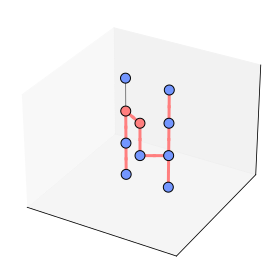

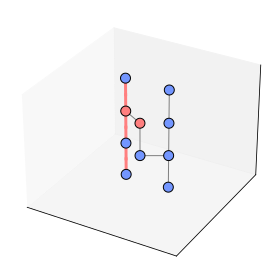

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs_lst[0], zx, ax)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs_lst[1], zx, ax)



In [6]:
#map correlation surface from zx to pipe diagram
cs = cs_lst[0]

vertex_ids = cs.span_vertices
positions_in_cs = {vid: zx.positions[vid] for vid in vertex_ids}

print("Positions involved in correlation surface:")
for vid, pos in positions_in_cs.items():
    print(f"  vertex {vid} → position {pos}")

# Then look up the actual cube objects in the block graph
prisms_in_cs = [prism for prism in g.prisms if prism.position in positions_in_cs.values()]
print("\nCubes involved:")
for cube in prisms_in_cs:
    print(f"  {cube.position}  kind={cube.kind}")

Positions involved in correlation surface:
  vertex 0 → position Position3DHex(x=3, y=3, z=0)
  vertex 1 → position Position3DHex(x=3, y=3, z=1)
  vertex 2 → position Position3DHex(x=3, y=3, z=2)
  vertex 3 → position Position3DHex(x=3, y=3, z=3)
  vertex 4 → position Position3DHex(x=2, y=2, z=1)
  vertex 5 → position Position3DHex(x=2, y=2, z=2)
  vertex 6 → position Position3DHex(x=1, y=3, z=0)
  vertex 7 → position Position3DHex(x=1, y=3, z=1)
  vertex 8 → position Position3DHex(x=1, y=3, z=2)

Cubes involved:
  Position3DHex(x=3, y=3, z=0)  kind=XN
  Position3DHex(x=3, y=3, z=1)  kind=NN
  Position3DHex(x=3, y=3, z=2)  kind=NN
  Position3DHex(x=3, y=3, z=3)  kind=NX
  Position3DHex(x=2, y=2, z=1)  kind=XN
  Position3DHex(x=2, y=2, z=2)  kind=NZ
  Position3DHex(x=1, y=3, z=0)  kind=XN
  Position3DHex(x=1, y=3, z=1)  kind=NN
  Position3DHex(x=1, y=3, z=2)  kind=NN


stabilizer tests passed
stabilizer tests passed


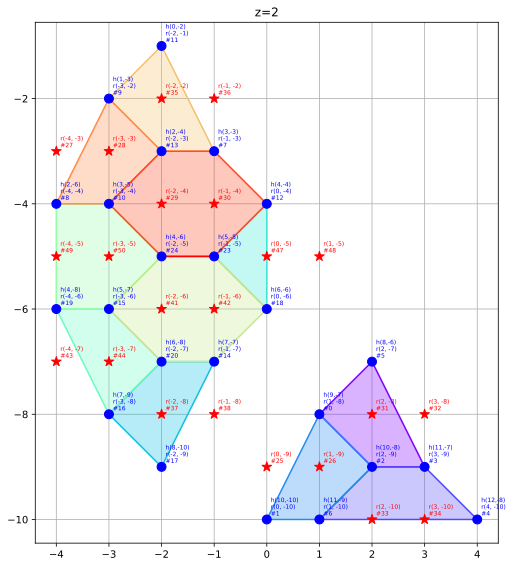

In [7]:
d=3
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 2
temp_utils.plot_mapping_full(mapping_full, z_temp)

test horizontal correlation surface construction

In [8]:

z=1

stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers = SE.prism_graph.stabilizers_timeslice(z, SE.d)
result = SE.prism_graph.stabilizer_product_timeslice(z, SE.d, dct_single_type_stabs, dct_patch_stabilizers, testing = True)

stabilizer tests passed


In [9]:
d=7
rounds = d
p = 0.00


SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = cs_lst
)

stabilizer tests passed
stabilizer tests passed


In [10]:
for z in SE.z_values:
    print(f"z={z}")
    result = SE.result_dct[z]["product"]
    stabilizer_products_x = result.stabilizer_products_x
    stabilizer_products_z = result.stabilizer_products_z
    print("len x product", len(stabilizer_products_x))
    print("len z product", len(stabilizer_products_z))

z=0
len x product 0
len z product 0
z=1
len x product 0
len z product 1
z=2
len x product 1
len z product 0
z=3
len x product 0
len z product 0


In [11]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_CNOT_d{d}.svg", "w") as f:
    f.write(str(svg))

In [12]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
Detectors that fired: []


In [13]:
dem = circuit.detector_error_model()

In [14]:
dem = circuit.detector_error_model()
import stim

for instruction in dem.flattened():
    if instruction.type == "error":
        detectors = [t for t in instruction.targets_copy() 
                     if t.is_relative_detector_id()]
        logicals = [t for t in instruction.targets_copy() 
                    if t.is_logical_observable_id()]
        
        if len(detectors) == 0:
            print(f"Undetected error (p={instruction.args_copy()[0]}):")
            print(f"  Flips observables: {logicals}")
            print(f"  Full instruction: {instruction}")
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)

detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}, {[el-circuit.num_measurements for el in d]}")


In [15]:
"""
rec_to_label = {
    info.abs_rec: info.label
    for info in SE.meas_rec_lst
}

rec_to_info = {
    info.abs_rec: info
    for info in SE.meas_rec_lst
}

for abs_rec in d:
    print(abs_rec)
    info = rec_to_info[abs_rec+1]
    print(info.label)
    print(info.meas_type)
    print("----")
"""

'\nrec_to_label = {\n    info.abs_rec: info.label\n    for info in SE.meas_rec_lst\n}\n\nrec_to_info = {\n    info.abs_rec: info\n    for info in SE.meas_rec_lst\n}\n\nfor abs_rec in d:\n    print(abs_rec)\n    info = rec_to_info[abs_rec+1]\n    print(info.label)\n    print(info.meas_type)\n    print("----")\n'

In [16]:
"""
for abs_rec in []:
    print(abs_rec)
    info = rec_to_info[abs_rec+1]
    print(info.label)
    print(info.meas_type)
    print("----")
"""

'\nfor abs_rec in []:\n    print(abs_rec)\n    info = rec_to_info[abs_rec+1]\n    print(info.label)\n    print(info.meas_type)\n    print("----")\n'

In [17]:
len(circuit.shortest_graphlike_error())

ValueError: Failed to find any graphlike logical errors.
    WARNING: NO ERRORS. The circuit or detector error model didn't include any errors, making it vacuously impossible to find a logical error.

In [ ]:
errors = circuit.search_for_undetectable_logical_errors(
    dont_explore_detection_event_sets_with_size_above=d,
    dont_explore_edges_with_degree_above=2,
    dont_explore_edges_increasing_symptom_degree=True,
)
d = len(errors)
print(d)

7


stim.Circuit('''
    QUBIT_COORDS(0, 0) 0
    QUBIT_COORDS(0, 2) 1
    QUBIT_COORDS(0, 4) 2
    QUBIT_COORDS(0, 6) 3
    QUBIT_COORDS(0, 8) 4
    QUBIT_COORDS(0, 10) 5
    QUBIT_COORDS(0, 12) 6
    QUBIT_COORDS(0, 14) 7
    QUBIT_COORDS(0, 16) 8
    QUBIT_COORDS(0, 18) 9
    QUBIT_COORDS(0, 20) 10
    QUBIT_COORDS(0, 22) 11
    QUBIT_COORDS(1, 1) 12
    QUBIT_COORDS(1, 3) 13
    QUBIT_COORDS(1, 5) 14
    QUBIT_COORDS(1, 7) 15
    QUBIT_COORDS(1, 9) 16
    QUBIT_COORDS(1, 11) 17
    QUBIT_COORDS(1, 13) 18
    QUBIT_COORDS(1, 15) 19
    QUBIT_COORDS(1, 17) 20
    QUBIT_COORDS(1, 19) 21
    QUBIT_COORDS(1, 21) 22
    QUBIT_COORDS(2, 0) 23
    QUBIT_COORDS(2, 2) 24
    QUBIT_COORDS(2, 4) 25
    QUBIT_COORDS(2, 6) 26
    QUBIT_COORDS(2, 8) 27
    QUBIT_COORDS(2, 10) 28
    QUBIT_COORDS(2, 12) 29
    QUBIT_COORDS(2, 14) 30
    QUBIT_COORDS(2, 16) 31
    QUBIT_COORDS(2, 18) 32
    QUBIT_COORDS(2, 20) 33
    QUBIT_COORDS(2, 22) 34
    QUBIT_COORDS(3, 1) 35
    QUBIT_COORDS(3, 3) 36
    QUBIT_C

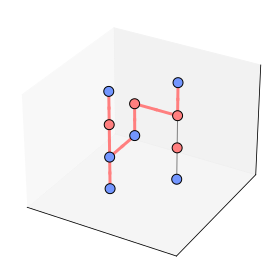

In [40]:
from tqec.gallery.cnot import cnot
from tqec import compile_block_graph 

g_sc = cnot(Basis.X)
correlation_surfaces = g_sc.find_correlation_surfaces()

idx = 1

cs_sc = correlation_surfaces[idx]
zx_sc = g_sc.to_zx_graph()

compiled_computation = compile_block_graph(g_sc, observables=[cs_sc])

circuit = compiled_computation.generate_stim_circuit(
    k=2,
)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx_sc, ax, node_size=100)
draw_correlation_surface_on(cs_sc, zx_sc, ax)

circuit

## Understand missing detectors on the logical level only

In [50]:
#stim circuit with a ZZ and XX measurement and find detectors
import stim

circuit = stim.Circuit()

# Initialize all qubits in |+>
circuit.append("RX", [0])
circuit.append("RX", [1])
circuit.append("RX", [2])

# Measure Z2 * Z1
circuit.append("MPP", [
    stim.target_z(2),
    stim.target_combiner(),
    stim.target_z(1),
])

# Measure X1 * X0
circuit.append("MPP", [
    stim.target_x(1),
    stim.target_combiner(),
    stim.target_x(0),
])

# Measure all qubits in the X basis
circuit.append("MX", [0])
circuit.append("MX", [1])
circuit.append("MX", [2])

# Observable 0 = final X measurement of qubit 2
circuit.append(
    "OBSERVABLE_INCLUDE",
    [stim.target_rec(-2)],
    0,
)


print(circuit)

RX 0 1 2
MPP Z2*Z1 X1*X0
MX 0 1 2
OBSERVABLE_INCLUDE(0) rec[-2]


In [51]:
dem = circuit.detector_error_model()

ValueError: The circuit contains non-deterministic observables.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['L0', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords L0 > output_image.svg

This was discovered while analyzing a Pauli product measurement (MPP) on:
    qubit 1

The collapse anti-commuted with these detectors/observables:
    L0

The backward-propagating error sensitivity for L0 was:
    X1

Circuit stack trace:
    at instruction #2 [which is MPP Z2*Z1 X1*X0]

## Smaller example for finding missing detectors

In [302]:
g = PrismGraph("singleLS")

prisms = [
    (Position3DHex(3,3,0), "XN", "1-in"),
    (Position3DHex(3,3,1), "NN", ""),
    (Position3DHex(3,3,2), "NX", "1-out"),

    (Position3DHex(2,2,0), "XN", "2-in"),
    (Position3DHex(2,2,1), "NN", ""),
    (Position3DHex(2,2,2), "NX", "2-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[3][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)



g.view_as_html()

In [303]:
zx = g.to_zx_graph()
correlation_surfaces = g.find_correlation_surfaces()
print("len correlation surfaces", len(correlation_surfaces))

idx = 0

cs = correlation_surfaces[idx]

"""
#CUSTOM CS
from tqec.computation.correlation import (
    CorrelationSurface,
    ZXEdge,
    ZXNode,
)
from tqec.utils.enums import Basis
cs = CorrelationSurface(
    frozenset({
        ZXEdge(
            ZXNode(0, Basis.X),
            ZXNode(1, Basis.X),
        ),
        ZXEdge(
            ZXNode(1, Basis.X),
            ZXNode(4, Basis.X),
        ),
        ZXEdge(
            ZXNode(4, Basis.X),
            ZXNode(5, Basis.X),
        ),
    })
)
"""


print(cs)
horizontal_pipes_cs = g.find_ver_hor_correlation_surface(cs)

for key, val in horizontal_pipes_cs.items():
    print(key)
    print(val)
    print("===")

len correlation surfaces 3
CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X))}))


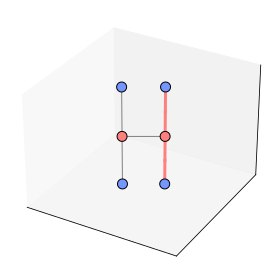

In [304]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


stabilizer tests passed


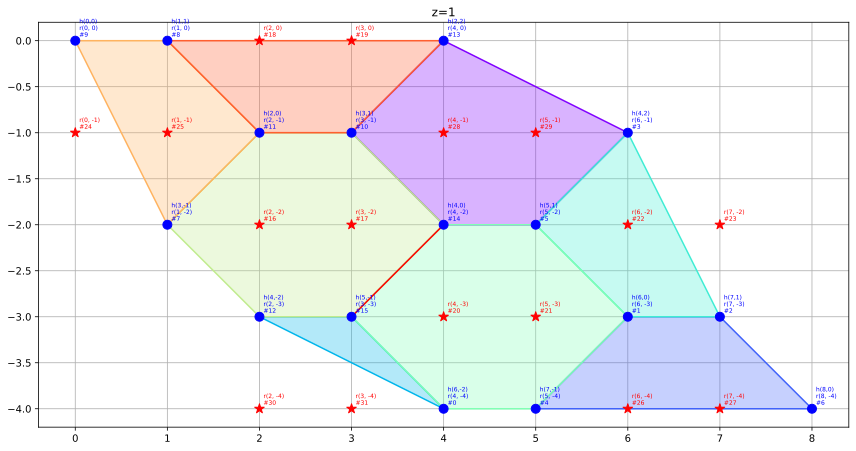

In [305]:
d=3
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 1
temp_utils.plot_mapping_full(mapping_full, z_temp)

In [306]:
d=9
rounds = d
p = 0.01


SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs = cs
)

stabilizer tests passed
horizontal_pipes_cs
========================z=0=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=20, y=-6, z=0), rect=(14, -13), label=23), PositionEntry(hex=Position3DHex(x=21, y=-5, z=0), rect=(15, -13), label=9)]
lst [23, 134]
lst [9, 135]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=18, y=-8, z=0), rect=(10, -13), label=10), PositionEntry(hex=Position3DHex(x=19, y=-7, z=0), rect=(11, -13), label=16)]
lst [10, 142]
lst [16, 143]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=22, y=0, z=0), rect=(22, -11), label=60), PositionEntry(hex=Position3DHex(x=23, y=1, z=0), rect=(23, -11), label=22)]
lst [60, 146]
lst [22, 147]
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=16, y=4, z=0), rect=(20, -6), label=33), PositionEntry(hex=Position3DHex(x=17, y=5, z=0), rect=(21, -6), label=39)]
lst [33, 150]
lst [39, 151]
stabtype XZ, Z stab
entries [PositionE

In [307]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_singleLS_d{d}.svg", "w") as f:
    f.write(str(svg))

In [308]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? True
Detectors that fired: [   0    1    2 ... 3309 3310 3311]
  D0: fired in 23/100 shots
  D1: fired in 19/100 shots
  D2: fired in 32/100 shots
  D3: fired in 22/100 shots
  D4: fired in 24/100 shots
  D5: fired in 24/100 shots
  D6: fired in 23/100 shots
  D7: fired in 22/100 shots
  D8: fired in 25/100 shots
  D9: fired in 23/100 shots
  D10: fired in 17/100 shots
  D11: fired in 22/100 shots
  D12: fired in 27/100 shots
  D13: fired in 15/100 shots
  D14: fired in 18/100 shots
  D15: fired in 20/100 shots
  D16: fired in 24/100 shots
  D17: fired in 19/100 shots
  D18: fired in 28/100 shots
  D19: fired in 25/100 shots
  D20: fired in 19/100 shots
  D21: fired in 16/100 shots
  D22: fired in 23/100 shots
  D23: fired in 23/100 shots
  D24: fired in 17/100 shots
  D25: fired in 27/100 shots
  D26: fired in 18/100 shots
  D27: fired in 24/100 shots
  D28: fired in 19/100 shots
  D29: fired in 21/100 shots
  D30: fired in 27/100 shots
  D31: fired in 26/100 shot

In [309]:

dem = circuit.detector_error_model()
import stim

for instruction in dem.flattened():
    if instruction.type == "error":
        detectors = [t for t in instruction.targets_copy() 
                     if t.is_relative_detector_id()]
        logicals = [t for t in instruction.targets_copy() 
                    if t.is_logical_observable_id()]
        
        if len(detectors) == 0:
            print(f"Undetected error (p={instruction.args_copy()[0]}):")
            print(f"  Flips observables: {logicals}")
            print(f"  Full instruction: {instruction}")
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)

detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}, {[el-circuit.num_measurements for el in d]}")
    rec_to_info = {
        info.abs_rec: info
        for info in SE.meas_rec_lst
    }
    for abs_rec in d:
        print(abs_rec)
        info = rec_to_info[abs_rec+1]
        print(info.label)
        print(info.meas_type)
        print("----")


Detector 0: [2118, 2145, 2158, 2159, 2166, 2237, 2238, 2239, 2240], [-1333, -1306, -1293, -1292, -1285, -1214, -1213, -1212, -1211]
2118
250
MX
----
2145
252
MX
----
2158
254
MX
----
2159
256
MX
----
2166
258
MX
----
2237
123
MX
----
2238
124
MX
----
2239
127
MX
----
2240
126
MX
----
Detector 1: [3419, 3422, 3425, 3431, 3435, 3438, 3439, 3440, 3444], [-32, -29, -26, -20, -16, -13, -12, -11, -7]
3419
68
MX
----
3422
69
MX
----
3425
74
MX
----
3431
80
MX
----
3435
84
MX
----
3438
87
MX
----
3439
88
MX
----
3440
90
MX
----
3444
95
MX
----


In [310]:
lst_temp = []
for abs_rec in lst_temp:
    print(abs_rec)
    info = rec_to_info[abs_rec+1]
    print(info.label)
    print(info.meas_type)
    print("----")

In [311]:
len(circuit.shortest_graphlike_error())

9

## example with surface code

https://tqec.github.io/tqec/user_guide/quick_start.html

In [34]:
from tqec import BlockGraph
from tqec.gallery.cnot import cnot
from tqec import Basis

block_graph = cnot(Basis.Z)

correlation_surfaces = block_graph.find_correlation_surfaces()

idx = 1

cs = correlation_surfaces[idx]
zx = block_graph.to_zx_graph()


block_graph.view_as_html()

In [35]:
from tqec.computation.correlation import (
    CorrelationSurface,
    ZXEdge,
    ZXNode,
)
from tqec.utils.enums import Basis

"""
cs = CorrelationSurface(
    frozenset({
        ZXEdge(
            ZXNode(6, Basis.X),
            ZXNode(7, Basis.X),
        ),
        ZXEdge(
            ZXNode(7, Basis.X),
            ZXNode(8, Basis.X),
        ),
        ZXEdge(
            ZXNode(8, Basis.X),
            ZXNode(9, Basis.X),
        ),
    })
)
"""

'\ncs = CorrelationSurface(\n    frozenset({\n        ZXEdge(\n            ZXNode(6, Basis.X),\n            ZXNode(7, Basis.X),\n        ),\n        ZXEdge(\n            ZXNode(7, Basis.X),\n            ZXNode(8, Basis.X),\n        ),\n        ZXEdge(\n            ZXNode(8, Basis.X),\n            ZXNode(9, Basis.X),\n        ),\n    })\n)\n'

In [36]:
# After creating your zx graph:
zx = block_graph.to_zx_graph()  # returns a PositionedZXGraph

# Option 1: print all node positions
for node, pos in zx.positions.items():
    print(f"node {node}: {pos}")

node 0: (0,0,0)
node 1: (0,0,1)
node 2: (0,0,2)
node 3: (0,0,3)
node 4: (0,1,1)
node 5: (0,1,2)
node 6: (1,1,0)
node 7: (1,1,1)
node 8: (1,1,2)
node 9: (1,1,3)


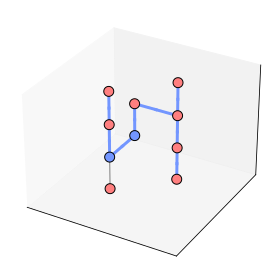

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


In [ ]:
from tqec import compile_block_graph

compiled_computation = compile_block_graph(block_graph, observables=[correlation_surfaces[idx]])

AttributeError: 'TopologicalComputationGraph' object has no attribute 'observables'

In [94]:
from tqec import NoiseModel

circuit = compiled_computation.generate_stim_circuit(
    k=1,
    noise_model=NoiseModel.uniform_depolarizing(0.001),
)

In [95]:
zx = block_graph.to_zx_graph()
cs = correlation_surfaces[idx_obs]

# Get the vertex IDs in the correlation surface
vertex_ids = cs.span_vertices  # set[int]

# Map each vertex ID back to its 3D position (= cube/prism position)
positions_in_cs = {vid: zx.positions[vid] for vid in vertex_ids}

print("Positions involved in correlation surface:")
for vid, pos in positions_in_cs.items():
    print(f"  vertex {vid} → position {pos}")

# Then look up the actual cube objects in the block graph
cubes_in_cs = [cube for cube in block_graph.cubes if cube.position in positions_in_cs.values()]
print("\nCubes involved:")
for cube in cubes_in_cs:
    print(f"  {cube.position}  kind={cube.kind}")

Positions involved in correlation surface:
  vertex 0 → position (0,0,0)
  vertex 1 → position (0,0,1)
  vertex 2 → position (0,0,2)
  vertex 3 → position (0,0,3)
  vertex 4 → position (0,1,1)
  vertex 5 → position (0,1,2)
  vertex 8 → position (1,1,2)
  vertex 9 → position (1,1,3)

Cubes involved:
  (0,0,0)  kind=ZXX
  (0,0,1)  kind=ZXX
  (0,0,2)  kind=ZXZ
  (0,0,3)  kind=ZXX
  (0,1,1)  kind=ZXX
  (0,1,2)  kind=ZXZ
  (1,1,2)  kind=ZXZ
  (1,1,3)  kind=ZXX


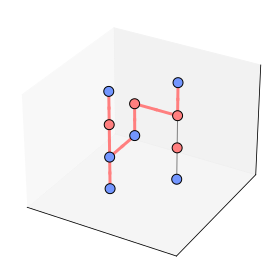

In [96]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


In [111]:
circuit

stim.Circuit('''
    QUBIT_COORDS(0, 0) 0
    QUBIT_COORDS(0, 2) 1
    QUBIT_COORDS(0, 4) 2
    QUBIT_COORDS(0, 6) 3
    QUBIT_COORDS(0, 8) 4
    QUBIT_COORDS(0, 10) 5
    QUBIT_COORDS(0, 12) 6
    QUBIT_COORDS(0, 14) 7
    QUBIT_COORDS(1, 1) 8
    QUBIT_COORDS(1, 3) 9
    QUBIT_COORDS(1, 5) 10
    QUBIT_COORDS(1, 7) 11
    QUBIT_COORDS(1, 9) 12
    QUBIT_COORDS(1, 11) 13
    QUBIT_COORDS(1, 13) 14
    QUBIT_COORDS(2, 0) 15
    QUBIT_COORDS(2, 2) 16
    QUBIT_COORDS(2, 4) 17
    QUBIT_COORDS(2, 6) 18
    QUBIT_COORDS(2, 8) 19
    QUBIT_COORDS(2, 10) 20
    QUBIT_COORDS(2, 12) 21
    QUBIT_COORDS(2, 14) 22
    QUBIT_COORDS(3, 1) 23
    QUBIT_COORDS(3, 3) 24
    QUBIT_COORDS(3, 5) 25
    QUBIT_COORDS(3, 7) 26
    QUBIT_COORDS(3, 9) 27
    QUBIT_COORDS(3, 11) 28
    QUBIT_COORDS(3, 13) 29
    QUBIT_COORDS(4, 0) 30
    QUBIT_COORDS(4, 2) 31
    QUBIT_COORDS(4, 4) 32
    QUBIT_COORDS(4, 6) 33
    QUBIT_COORDS(4, 8) 34
    QUBIT_COORDS(4, 10) 35
    QUBIT_COORDS(4, 12) 36
    QUBIT_COORDS(4,

In [85]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_SC_CNOT_d{d}.svg", "w") as f:
    f.write(str(svg))

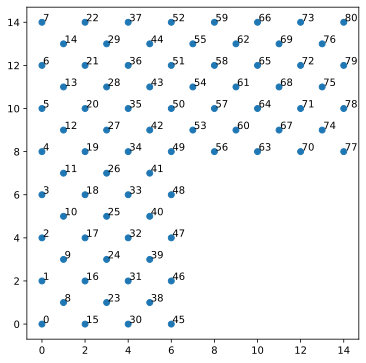

In [113]:
#circuit.diagram("interactive-html")
coords = []

for inst in circuit:
    if inst.name == "QUBIT_COORDS":
        x, y = inst.gate_args_copy()
        q = inst.targets_copy()[0].value
        coords.append((q, x, y))

import matplotlib.pyplot as plt

xs = []
ys = []
labels = []

for q, x, y in coords:
    xs.append(x)
    ys.append(y)
    labels.append(str(q))

plt.figure(figsize=(6, 6))
plt.scatter(xs, ys)

for x, y, label in zip(xs, ys, labels):
    plt.text(x + 0.05, y + 0.05, label, fontsize=10)

plt.gca().set_aspect("equal")
plt.show()

In [ ]:
from multiprocessing import cpu_count
import numpy as np
from pathlib import Path

from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter


# returns a iterator
stats = start_simulation_using_sinter(
    block_graph,
    ks=range(1, 4),  # k values for the code distance
    ps=list(np.logspace(-4, -1, 10)),  # error rates
    noise_model_factory=NoiseModel.uniform_depolarizing,  # noise model
    manhattan_radius=2,  # parameter for automatic detector computation
    observables=[correlation_surfaces[1]],  # observable of interest
    decoders=["pymatching"],
    num_workers=cpu_count(),
    max_shots=1_000_000,
    max_errors=400,
    save_resume_filepath=Path("./_examples_database/quick_start.csv"),
    database_path=Path("./_examples_database/database.pkl"),
)

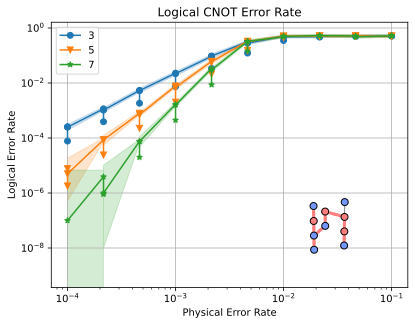

In [38]:
import matplotlib.pyplot as plt
import sinter

from tqec.simulation.plotting.inset import plot_observable_as_inset

zx_graph = block_graph.to_zx_graph()

fig, ax = plt.subplots()
# len(stats) = 1 if we have multiple we can iterate over the results
sinter.plot_error_rate(
    ax=ax,
    stats=next(iter(stats)),
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["d"],
)
plot_observable_as_inset(ax, zx_graph, correlation_surfaces[idx_obs])
ax.grid(axis="both")
ax.legend()
ax.loglog()
ax.set_title("Logical CNOT Error Rate")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
plt.show()

Further examples with surface code

In [2]:
from tqec import BlockGraph

block_graph = BlockGraph.from_dae_file("diagram_cnot_compact.dae")

In [3]:
block_graph.view_as_html()

In [4]:
zx = block_graph.to_zx_graph()

correlation_surfaces = block_graph.find_correlation_surfaces()

idx = 0

cs = correlation_surfaces[idx]

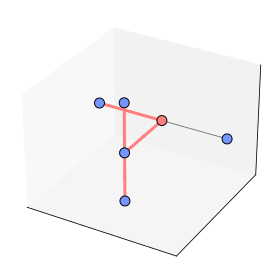

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


In [6]:
from multiprocessing import cpu_count
import numpy as np
from pathlib import Path

from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter


# returns a iterator
stats = start_simulation_using_sinter(
    block_graph,
    ks=range(1, 4),  # k values for the code distance
    ps=list(np.logspace(-3, -1, 10)),  # error rates
    noise_model_factory=NoiseModel.uniform_depolarizing,  # noise model
    manhattan_radius=2,  # parameter for automatic detector computation
    observables=[correlation_surfaces[1]],  # observable of interest
    decoders=["pymatching"],
    num_workers=cpu_count(),
    max_shots=1_000_000,
    max_errors=400,
    save_resume_filepath=Path("./_examples_database/quick_start.csv"),
    database_path=Path("./_examples_database/database.pkl"),
)

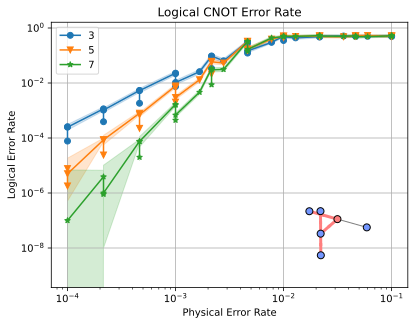

In [8]:
import matplotlib.pyplot as plt
import sinter

from tqec.simulation.plotting.inset import plot_observable_as_inset

zx_graph = block_graph.to_zx_graph()

fig, ax = plt.subplots()
# len(stats) = 1 if we have multiple we can iterate over the results
sinter.plot_error_rate(
    ax=ax,
    stats=next(iter(stats)),
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["d"],
)
plot_observable_as_inset(ax, zx_graph, correlation_surfaces[idx])
ax.grid(axis="both")
ax.legend()
ax.loglog()
ax.set_title("Logical CNOT Error Rate")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
plt.show()